<a href="https://colab.research.google.com/github/vzyhug/200123035_14DHTH07_DL/blob/main/CNN/CNN_multiclass_classification_prj1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORT LIB

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# Lấy danh sách các thiết bị GPU có sẵn
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print("✅ Đang chạy trên GPU!")
    for device in gpu_devices:
        print(f" - Chi tiết thiết bị: {device.name}")
else:
    print("❌ Không tìm thấy GPU. Đang chạy trên CPU (sẽ rất chậm).")
    print("💡 Mẹo: Vào menu 'Thời gian chạy' (Runtime) -> 'Thay đổi loại thời gian chạy' (Change runtime type) -> Chọn T4 GPU.")

✅ Đang chạy trên GPU!
 - Chi tiết thiết bị: /physical_device:GPU:0


## DATA

In [2]:
# Cài đặt thư viện kaggle
!pip install -q kaggle

# Bạn cần upload file kaggle.json (API token) của bạn lên Colab trước khi chạy bước này
# Tạo thư mục ẩn để chứa API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Tải dataset trực tiếp
!kaggle datasets download -d siddharthkumarsah/logo-dataset-2341-classes-and-167140-images

# Giải nén dữ liệu
!unzip -q logo-dataset-2341-classes-and-167140-images.zip -d logo_dataset

Dataset URL: https://www.kaggle.com/datasets/siddharthkumarsah/logo-dataset-2341-classes-and-167140-images
License(s): copyright-authors
100% 1.91G/1.91G [00:14<00:00, 145MB/s]



## PREPROCESSING

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Định nghĩa lại đường dẫn cho cả Train và Test
train_dir = 'logo_dataset/datasetcopy/trainandtest/train'
test_dir = 'logo_dataset/datasetcopy/trainandtest/test'

# Tham số ảnh
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 64

# 1. Datagen cho Train & Validation (Lấy từ thư mục train, chia 80/20)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest',
    validation_split=0.2  # Chia 20% ra làm Validation
)

# 2. Datagen cho Test (Chỉ scale pixel, KHÔNG data augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Đang chuẩn bị tập TRAINING ---")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'     # Lấy 80%
)

print("\n--- Đang chuẩn bị tập VALIDATION ---")
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'   # Lấy 20%
)

print("\n--- Đang chuẩn bị tập TEST ---")
test_generator = test_datagen.flow_from_directory(
    test_dir,             # Trỏ vào thư mục test gốc
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

--- Đang chuẩn bị tập TRAINING ---
Found 133497 images belonging to 10 classes.

--- Đang chuẩn bị tập VALIDATION ---
Found 33369 images belonging to 10 classes.

--- Đang chuẩn bị tập TEST ---
Found 50173 images belonging to 10 classes.


## TRAIN

In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

num_classes = 10

# 1. Định nghĩa lại mô hình chuẩn Keras mới
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Đã sửa cảnh báo input_shape
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Tránh overfitting
    layers.Dense(num_classes, activation='softmax')
])

# 2. Biên dịch mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Tạo Callbacks để tự động lưu & dừng sớm
callbacks = [
    # Lưu lại model tốt nhất dựa trên val_accuracy
    ModelCheckpoint(
        filepath='best_logo_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Dừng sớm nếu sau 3 epoch val_loss không giảm
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

# 4. Bắt đầu huấn luyện
print("Bắt đầu quá trình huấn luyện... Vui lòng giữ tab mở!")
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks # Truyền callback vào đây
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,943,946 (49.38 MB)

 Trainable params: 12,943,946 (49.38 MB)

 Non-trainable params: 0 (0.00 B)

Bắt đầu quá trình huấn luyện... Vui lòng giữ tab mở!
Epoch 1/30
  17/2086 ━━━━━━━━━━━━━━━━━━━━ 9:45 283ms/step - accuracy: 0.2743 - loss: 2.1299

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
import shutil

# 1. Kết nối với Google Drive của bạn (sẽ có popup yêu cầu quyền truy cập)
drive.mount('/content/drive')

# 2. Lưu mô hình trên Colab trước
model.save('logo_classification_model.keras')

# 3. Copy file mô hình vừa lưu sang Google Drive
# Lưu ý: '/content/drive/MyDrive/' là thư mục gốc Drive của bạn
shutil.copy('logo_classification_model.keras', '/content/drive/MyDrive/logo_classification_model.keras')

print("Đã lưu mô hình an toàn vào Google Drive của bạn!")

## TRAIN RESULT

In [ ]:
import matplotlib.pyplot as plt

# Tạo khung ảnh cho 2 biểu đồ
plt.figure(figsize=(15, 5))

# 1. Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='#deff9a')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#daffde')
plt.title('Model Loss Performance')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#deff9a')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#daffde')
plt.title('Model Accuracy Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Block 2: Vẽ Ma trận nhầm lẫn (Confusion Matrix)
Để ma trận chính xác, bạn cần dùng tập validation với tham số `shuffle=False`.
```python
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Dự đoán trên tập validation
# Lưu ý: Phải đảm bảo val_generator không bị shuffle (shuffle=False) để nhãn khớp với ảnh
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

# 2. Lấy nhãn thực tế
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# 3. Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# 4. Vẽ Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Logo Classification')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

# 5. In báo cáo chi tiết (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


## SIMPLE TEST

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


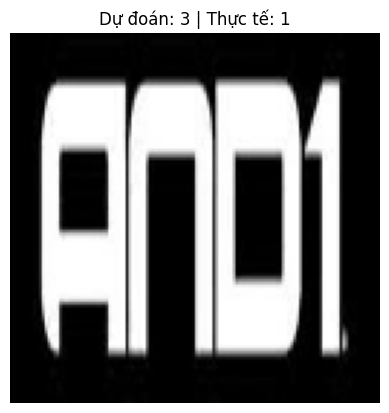

In [ ]:
# Lấy một batch dữ liệu từ tập validation
val_images, val_labels = next(val_generator)

# Lấy ảnh đầu tiên trong batch
test_image = val_images[0]
true_label_index = np.argmax(val_labels[0])

# Mở rộng chiều để dự đoán (model cần input dạng batch: (1, 128, 128, 3))
img_array = np.expand_dims(test_image, axis=0)
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])

# Hiển thị ảnh
plt.imshow(test_image)
plt.title(f"Dự đoán: {predicted_class_index} | Thực tế: {true_label_index}")
plt.axis('off')
plt.show()